# Simplified Implementation of V3 Methodology
In this notebook we'll implement the V3 Methodology developped after our call with M. Weibel. Generally speaking it combined V1 and V2 into a single unified methodology. Concretely this means:
- One set of features is the time-decayed average count of articles, separated into topics
- Second set of features is the time-decayed average embedding, followed by PCA dimension reduction.

A few limitation of this implementation:
- We'll only use the german_news_v1 dataset obtained in `/data`, because we haven't implemented any translation or finer preprocessing
- We'll use the `energy-charts.info` API, which can only return auction price, not spot price yet. This is because we haven't yet downloaded the entire relevant dataset yet.
- We will not run any hyperparameter-tuning in this notebook yet.

We'll make sure to code this notebook somewhat modular so that swapping out these features for the final notebook is easier.

---
## Importing Required Libraries
This section imports all necessary libraries for running the analysis in this notebook

In [10]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from tqdm import tqdm

# API libraries
import requests
import os
from dotenv import load_dotenv

# NLP libraries
import umap
import torch
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from datasets import Dataset

# ML Libraries
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Parallelization libraries
from joblib import Parallel, delayed

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

---
# Data Collection & Loading
## News Data
Here we only need to import `german_news_v1.csv` into a dataframe since we already collected and somewhat pre-processed it

In [11]:
news_df = pd.read_csv('german_news_v1.csv')

print(news_df.shape)
news_df.head(5)

(113894, 5)


,publishedAt,title,source,description,url
0,2020-11-01 07:57:31+00:00,Bis 2030 - Audi-Chef Duesmann: Verbrenner wird...,Focus,"Audi-Chef Duesmann glaubt nicht, dass sich Was...",https://www.focus.de/finanzen/boerse/bis-2030-...
1,2020-11-01 08:29:51+00:00,"""Ständige Vertretung"" - Rache für den Lockdown...",Focus,Wegen des anstehenden Lockdowns sind viele Wir...,https://www.focus.de/politik/deutschland/reakt...
2,2020-11-01 09:30:16+00:00,*** BILDplus Inhalt *** Frischluft gegen Coron...,Bild,"Weil Corona durch Aerosole übertragen wird, he...",https://www.bild.de/bild-plus/ratgeber/2020/ra...
3,2020-11-01 10:27:14+00:00,"US-Wahl: ""Trump hat mich zur Miss Pennsylvania...",Spiegel Online,Dank Trump war Gina Cerilli ein erfolgreiches ...,https://www.spiegel.de/politik/ausland/us-wahl...
4,2020-11-01 11:13:44+00:00,13-Jähriger im Monbijoupark erstochen,Der Tagesspiegel,Ein 13-Jähriger ist in der Nacht zum Sonntag i...,https://www.tagesspiegel.de/berlin/schrecklich...


## Energy Data
Similar to V1 and V2 implementation we'll use the `energy-charts.info` API to pull 1 year worth of data for the auction price (which we will assume to be spot price in this notebook) and the total power generated.

In [12]:
def fetch_energy_charts_data(start_date: str, end_date: str, bidding_zone: str = 'DE-LU') -> pd.DataFrame:
    """
    Fetch hourly price and power generation data from Energy Charts API.
    
    Parameters:
        start_date (str): Start date in format 'YYYY-MM-DD'
        end_date (str): End date in format 'YYYY-MM-DD'
        bidding_zone (str): Bidding zone code (default: 'DE-LU' for Germany/Luxembourg)
    
    Returns:
        pd.DataFrame: DataFrame with datetime index and columns: 'price', 'total_power'
    """
    base_url = "https://api.energy-charts.info"
    
    price_url = f"{base_url}/price"
    price_params = {
        'bzn': bidding_zone,
        'start': start_date,
        'end': end_date
    }
    
    try:
        price_response = requests.get(price_url, params=price_params, timeout=30)
        price_response.raise_for_status()
        price_data = price_response.json()
    except requests.exceptions.RequestException as e:
        raise requests.exceptions.RequestException(f"Error fetching price data: {e}")
    
    power_url = f"{base_url}/total_power"
    power_params = {
        'country': 'de',
        'start': start_date,
        'end': end_date
    }
    
    try:
        power_response = requests.get(power_url, params=power_params, timeout=30)
        power_response.raise_for_status()
        power_data = power_response.json()
    except requests.exceptions.RequestException as e:
        raise requests.exceptions.RequestException(f"Error fetching power data: {e}")
    
    if 'unix_seconds' in price_data and 'price' in price_data:
        price_timestamps = pd.to_datetime(price_data['unix_seconds'], unit='s')
        prices = price_data['price']
        price_df = pd.DataFrame({'price': prices}, index=price_timestamps)
    else:
        raise ValueError("Unexpected price data structure")
    
    if 'unix_seconds' in power_data and 'production_types' in power_data:
        power_timestamps = pd.to_datetime(power_data['unix_seconds'], unit='s')
        
        total_power = np.zeros(len(power_timestamps))
        for production_type in power_data['production_types']:
            try:
                production_values = np.array(production_type['data'])
                total_power += production_values
            except Exception:
                continue
        
        power_df = pd.DataFrame({'total_power': total_power}, index=power_timestamps)
    else:
        raise ValueError("Unexpected power data structure")
    
    energy_df = price_df.join(power_df, how='outer')
    
    return energy_df

start_date = "2020-11-01"
end_date = "2025-10-31"


energy_df = fetch_energy_charts_data(start_date, end_date)
energy_df.head(5)


,price,total_power
2020-10-31 23:00:00,24.26,111222.8
2020-10-31 23:15:00,NaN,108556.2
2020-10-31 23:30:00,NaN,107452.9
2020-10-31 23:45:00,NaN,106207.3
2020-11-01 00:00:00,23.21,105772.9


In [13]:
# We get quarterly data for power, but hourly for price. We just drop NaN rows
energy_df = energy_df.dropna()
energy_df.head(5)

,price,total_power
2020-10-31 23:00:00,24.26,111222.8
2020-11-01 00:00:00,23.21,105772.9
2020-11-01 01:00:00,20.03,103850.1
2020-11-01 02:00:00,13.62,107071.7
2020-11-01 03:00:00,10.48,108373.0


---
# Feature Engineering
In this section we'll be computing the different features used in training our baseline and advanced models.

## Data Initialisation & Baseline Features
1. We copy the `energy_df`into `master_df`

2. We need to copy and shift the `price` column 24h back into `target` since our target variable is the next day price

3. We create a few lagged features:

    3.1. `price_lag_24` and `price_lag_168`

    3.2. `total_power_lag_24` and `total_power_lag_168`

4. Also create temporal features like `hour`, `week_of_year`, `month`, `day_of_week`, `day_of_year` and `week_of_year` to help with seasonality

5. Drop NaN values because of the shifts

In [14]:
master_df = energy_df.copy()

master_df['target'] = master_df['price'].shift(-24)

master_df['price_lag_24'] = master_df['price'].shift(24)
master_df['price_lag_168'] = master_df['price'].shift(168)
master_df['total_power_lag_24'] = master_df['total_power'].shift(24)
master_df['total_power_lag_168'] = master_df['total_power'].shift(168)

master_df['hour'] = master_df.index.hour
master_df['week_of_year'] = master_df.index.isocalendar().week
master_df['month'] = master_df.index.month
master_df['day_of_week'] = master_df.index.dayofweek
master_df['day_of_year'] = master_df.index.dayofyear

master_df = master_df.dropna()

print(master_df.columns)
master_df.head(25)

Index(['price', 'total_power', 'target', 'price_lag_24', 'price_lag_168',
       'total_power_lag_24', 'total_power_lag_168', 'hour', 'week_of_year',
       'month', 'day_of_week', 'day_of_year'],
      dtype='object')


,price,total_power,target,price_lag_24,price_lag_168,total_power_lag_24,total_power_lag_168,hour,week_of_year,month,day_of_week,day_of_year
2020-11-07 23:00:00,35.87,130407.5,32.50,35.05,24.26,139313.4,111222.8,23,45,11,5,312
2020-11-08 00:00:00,31.71,125331.6,32.08,31.65,23.21,134679.9,105772.9,0,45,11,6,313
2020-11-08 01:00:00,31.21,124077.6,31.95,31.16,20.03,133859.6,103850.1,1,45,11,6,313
2020-11-08 02:00:00,31.30,122810.1,31.10,29.91,13.62,132950.5,107071.7,2,45,11,6,313
2020-11-08 03:00:00,31.85,122059.4,31.00,29.05,10.48,132385.8,108373.0,3,45,11,6,313
2020-11-08 04:00:00,32.52,124339.8,33.15,28.70,10.01,132916.2,110939.7,4,45,11,6,313
2020-11-08 05:00:00,32.46,123315.6,44.37,30.33,11.23,132047.2,107132.5,5,45,11,6,313
2020-11-08 06:00:00,33.95,125840.1,48.88,30.84,6.56,139152.0,110443.2,6,45,11,6,313
2020-11-08 07:00:00,32.01,130440.6,49.95,34.62,10.08,147329.6,114476.1,7,45,11,6,313
2020-11-08 08:00:00,33.66,135178.7,48.00,34.58,18.01,151588.9,121488.5,8,45,11,6,313


## Topic Count Features
First we define 13 topics to classify news headlines into. These will be changed and optimised later down the line. 
2) 

In [15]:
candidate_labels = [
    # Energy consumption
    "der Strom- oder Energieverbrauch steigt deutlich",
    "der Strom- oder Energieverbrauch sinkt deutlich",

    # Energy production / generation availability
    "die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt",
    "die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt",

    # Commodity prices (gas/coal/oil)
    "die Preise für Erdgas, Kohle oder Öl steigen stark",
    "die Preise für Erdgas, Kohle oder Öl fallen stark",

    # Geopolitik und Versorgung
    "es gibt zunehmende geopolitische Spannungen oder Lieferengpässe bei Energie",
    "die geopolitischen Spannungen und Versorgungsprobleme gehen zurück",

    # Auswirkungen von Wetter in Deutschland auf Strompreise
    "in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise",
    "in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise",

    # Finanzmärkte
    "an den Finanzmärkten herrscht Instabilität oder Turbulenz",
    "an den Finanzmärkten herrscht Stabilität oder Beruhigung",

    # Catch-all
    "der Text hat keinen Bezug zu Energiepreisen, Wetter oder Finanzmärkten"
]

hypothesis_template = "Dieser Text legt nahe, dass {}."

We use Zero-Shot Classification to try and classify our news into the 13 topics as defined above. Some more work is needed when it comes to pre-processing and hypothesis crafting to ensure not too many articles fall into the catch-all category.

We use `ahajtomar/German_Zeroshot` as a model here, because it is a little bit more lightweight. In future itterations we might want to use `nahiar/zero-shot-classification` or another larger model for better results.

We also first try to classify news on their headline, since it's shorter and more efficient, then run through any articles that fell into the catch-all category again, but using their longer article description.

In [17]:
# GPU Optimization Settings
import os
# Set tokenizer parallelism to avoid warnings and improve performance
os.environ["TOKENIZERS_PARALLELISM"] = "true"

# Enable torch optimizations for better GPU utilization
torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # Clear any cached memory

# Check for device availability in order: CUDA -> MPS -> CPU
if torch.cuda.is_available():
    device = 0
    num_gpus = torch.cuda.device_count()
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)  # GB
    print(f"CUDA available: Using GPU 0 ({gpu_name})")
    print(f"GPU Memory: {gpu_memory:.1f} GB")
    print(f"Total GPUs: {num_gpus}")
    
    # Optimize batch size based on GPU memory
    # Larger GPUs (>16GB) can handle larger batches
    if gpu_memory >= 24:
        optimal_batch_size = 512
    elif gpu_memory >= 16:
        optimal_batch_size = 384
    elif gpu_memory >= 8:
        optimal_batch_size = 256
    else:
        optimal_batch_size = 128
    print(f"Optimal batch size for GPU: {optimal_batch_size}")
elif torch.backends.mps.is_available():
    device = "mps"
    optimal_batch_size = 256  # MPS typically handles this well
    print("MPS available: Using Apple Silicon GPU")
else:
    device = -1
    optimal_batch_size = 32
    print("No GPU available: Using CPU")

# Initialize pipeline with optimized settings
# Using fp16 (half precision) for faster inference and lower VRAM usage
classifier = pipeline(
    "zero-shot-classification",
    model="Sahajtomar/German_Zeroshot",
    device=device,
    batch_size=optimal_batch_size,
    torch_dtype=torch.float16 if device != -1 and device != "mps" else torch.float32  # fp16 on CUDA only

)

def classify_batch(texts, labels, hypothesis_template, batch_size=None, show_progress=True):
    """Classify a batch of texts using zero-shot classification with optimized GPU processing."""
    # Use optimal batch size if not specified
    if batch_size is None:
        batch_size = optimal_batch_size
    
    valid_texts = []
    valid_indices = []
    
    for idx, text in enumerate(texts):
        if pd.notna(text) and text.strip() != '':
            valid_texts.append(text)
            valid_indices.append(idx)

    if not valid_texts:
        return {}, {}

    classifications_dict = {}
    scores_dict = {}

    if show_progress:
        print(f"Processing {len(valid_texts)} texts with batch_size={batch_size} for efficient GPU utilization...")
    
    # Pass all texts at once - the pipeline will batch them internally
    # This approach eliminates sequential processing and maximizes GPU throughput
    # The pipeline uses the optimized batch_size and fp16 precision for better performance
    results = classifier(
        valid_texts,  # Pass all texts at once - pipeline handles batching
        labels,
        hypothesis_template=hypothesis_template,
        multi_label=False
    )
    
    # Handle both single result (dict) and multiple results (list)
    if isinstance(results, dict):
        results = [results]
    
    # Map results back to original indices
    for i, (idx, result) in enumerate(zip(valid_indices, results)):
        classifications_dict[idx] = result['labels'][0]
        scores_dict[idx] = result['scores'][0]

    # Fill in None for invalid texts
    for idx in range(len(texts)):
        if idx not in classifications_dict:
            classifications_dict[idx] = None
            scores_dict[idx] = 0.0

    return classifications_dict, scores_dict

titles = news_df['title'].tolist()
classifications_dict, scores_dict = classify_batch(
    titles, candidate_labels, hypothesis_template, batch_size=optimal_batch_size, show_progress=True
)

news_df['classification'] = [classifications_dict[i] for i in range(len(news_df))]
news_df['classification_score'] = [scores_dict[i] for i in range(len(news_df))]

other_mask = news_df['classification'] == "other (not related to these energy price drivers)"
num_other = other_mask.sum()

if num_other > 0:
    other_indices = news_df[other_mask].index
    descriptions = news_df.loc[other_indices, 'description'].tolist()
    
    other_classifications_dict, other_scores_dict = classify_batch(
        descriptions, candidate_labels, hypothesis_template, batch_size=optimal_batch_size, show_progress=True
    )
    
    for i, idx in enumerate(other_indices):
        news_df.loc[idx, 'classification'] = other_classifications_dict[i]
        news_df.loc[idx, 'classification_score'] = other_scores_dict[i]

final_other = (news_df['classification'] == "es ist nichts mit Energiepreisen, Wetter oder Finanzmärkten zu tun hat").sum()

print(f"Classification completed: {len(news_df)} articles processed")
print(f"Articles classified as 'other': {final_other} ({final_other/len(news_df)*100:.1f}%)")
print(f"\nClassification distribution:")
print(news_df['classification'].value_counts())
print(f"\nAverage score: {news_df['classification_score'].mean():.3f}")
print(f"Median score: {news_df['classification_score'].median():.3f}")

CUDA available: Using GPU 0 (NVIDIA GeForce RTX 4090)
GPU Memory: 23.6 GB
Total GPUs: 10
Optimal batch size for GPU: 384


Device set to use cuda:0


Processing 113893 texts with batch_size=384 for efficient GPU utilization...
Classification completed: 113894 articles processed
Articles classified as 'other': 0 (0.0%)

Classification distribution:
classification
an den Finanzmärkten herrscht Instabilität oder Turbulenz                                                                     29662
in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise              28684
in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise    27421
die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt                                                                 14946
die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt                                                                 3801
der Strom- oder Energieverbrauch sinkt deutlich                                                                              

In [18]:
print(news_df.head(5))

                 publishedAt  \
0  2020-11-01 07:57:31+00:00   
1  2020-11-01 08:29:51+00:00   
2  2020-11-01 09:30:16+00:00   
3  2020-11-01 10:27:14+00:00   
4  2020-11-01 11:13:44+00:00   

                                               title            source  \
0  Bis 2030 - Audi-Chef Duesmann: Verbrenner wird...             Focus   
1  "Ständige Vertretung" - Rache für den Lockdown...             Focus   
2  *** BILDplus Inhalt *** Frischluft gegen Coron...              Bild   
3  US-Wahl: "Trump hat mich zur Miss Pennsylvania...    Spiegel Online   
4              13-Jähriger im Monbijoupark erstochen  Der Tagesspiegel   

                                         description  \
0  Audi-Chef Duesmann glaubt nicht, dass sich Was...   
1  Wegen des anstehenden Lockdowns sind viele Wir...   
2  Weil Corona durch Aerosole übertragen wird, he...   
3  Dank Trump war Gina Cerilli ein erfolgreiches ...   
4  Ein 13-Jähriger ist in der Nacht zum Sonntag i...   

                         

## News Embeddings Features
Prior to aggregating topic counts, we will also create the embeddings for each article. We do this, because we want the embedding **with** classification for each article. This is done in case we want to keep or drop the catch-all topic, prior to computing the Time-Decayed weighted average.

In [26]:
def compute_embeddings(show_progress=True):
    """
    Compute embeddings for news headlines (titles only) using a pre-trained model. 
    The full embeddings should be inserted back into the `news_df` dataframe.
    
    Args:
        show_progress (bool): Whether to show a progress bar for the embedding computation.
    
    Returns:
        None (modifies news_df in place)
    """

    # GPU optimization: Clear cache before starting
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()  # Ensure all previous operations are complete
    
    if torch.cuda.is_available():
        device = "cuda"
        num_gpus = torch.cuda.device_count()
        gpu_name = torch.cuda.get_device_name(0)
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)  # GB
        print(f"CUDA available: {num_gpus} GPU(s) detected ({gpu_name})")
        print(f"GPU Memory: {gpu_memory:.1f} GB")
        # Note: SentenceTransformer doesn't support DataParallel - will use first GPU
        use_multi_gpu = False  # Changed: Disable DataParallel wrapping
        
        # Optimize batch size based on GPU memory for embeddings
        if gpu_memory >= 24:
            embedding_batch_size = 512
        elif gpu_memory >= 16:
            embedding_batch_size = 384
        elif gpu_memory >= 8:
            embedding_batch_size = 256
        else:
            embedding_batch_size = 128
    elif torch.backends.mps.is_available():
        device = "mps"
        use_multi_gpu = False
        embedding_batch_size = 256  # MPS typically handles this well
        print("MPS available: Using Apple Silicon GPU")
    else:
        device = "cpu"
        use_multi_gpu = False
        embedding_batch_size = 32
        print("No GPU available: Using CPU")
    
    # Initialize model with optimizations
    # SentenceTransformer automatically handles device placement
    model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)
    
    # Convert to half precision on CUDA for faster inference and lower VRAM usage
    if device == "cuda":
        try:
            # Convert model to half precision (fp16) if supported
            model = model.half()
            print("Model converted to fp16 (half precision) for faster GPU inference")
        except Exception as e:
            print(f"Note: Could not convert to fp16: {e}. Continuing with fp32.")
    
    # REMOVED: DataParallel wrapping - SentenceTransformer doesn't support this pattern
    # The model will use the first GPU by default which should be sufficient with proper batching
    
    # Extract only titles for embedding - optimized with list comprehension
    texts = [
        (news_df.loc[idx, 'title'] if pd.notna(news_df.loc[idx, 'title']) else '').strip() 
        if pd.notna(news_df.loc[idx, 'title']) else ''
        for idx in range(len(news_df))
    ]
    
    # Compute embeddings in batches for efficiency with optimized batch size
    batch_size = embedding_batch_size
    print(f"Using batch_size={batch_size} for embedding computation")
    embeddings = []
    
    print(f"Computing embeddings for {len(texts)} articles using device: {device}")
    
    # Setup progress bar, optionally
    iter_range = range(0, len(texts), batch_size)
    if show_progress:
        iter_range = tqdm(iter_range, desc="Computing embeddings")

    for i in iter_range:
        batch_texts = texts[i:i+batch_size]
        # Ensure the *internal* model.encode progress bar is off to avoid nested bars
        # Use normalize_embeddings=False for faster computation (if not needed)
        # Use convert_to_numpy=True to move results off GPU immediately
        batch_embeddings = model.encode(
            batch_texts, 
            convert_to_numpy=True, 
            show_progress_bar=False,
            batch_size=batch_size,  # Explicit batch size for internal processing
            normalize_embeddings=False  # Disable normalization for speed if not required
        )
        embeddings.extend(batch_embeddings)
        
        # Clear GPU cache periodically if using CUDA (every 10 batches to avoid overhead)
        if device == "cuda" and (i // batch_size) % 10 == 0:
            torch.cuda.empty_cache()
    
    # Convert to numpy array and store in dataframe
    embeddings_array = np.array(embeddings)
    news_df['embedding'] = [emb for emb in embeddings_array]
    
    # Final GPU cleanup
    if device == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    
    print(f"Embeddings computed: shape {embeddings_array.shape}")
    print(f"Embedding dimension: {embeddings_array.shape[1]}")
    if device != "cpu":
        if torch.cuda.is_available():
            memory_used = torch.cuda.max_memory_allocated(0) / (1024**3)
            print(f"Peak GPU memory used: {memory_used:.2f} GB")
    
    return None

compute_embeddings(show_progress=True)

CUDA available: 10 GPU(s) detected (NVIDIA GeForce RTX 4090)
GPU Memory: 23.6 GB
Model converted to fp16 (half precision) for faster GPU inference
Using batch_size=384 for embedding computation
Computing embeddings for 113894 articles using device: cuda


Computing embeddings: 100%|██████████| 297/297 [00:09<00:00, 29.86it/s]


Embeddings computed: shape (113894, 384)
Embedding dimension: 384
Peak GPU memory used: 1.73 GB


In [27]:
print(news_df.shape)
print(news_df.head(5))

(113894, 8)
                 publishedAt  \
0  2020-11-01 07:57:31+00:00   
1  2020-11-01 08:29:51+00:00   
2  2020-11-01 09:30:16+00:00   
3  2020-11-01 10:27:14+00:00   
4  2020-11-01 11:13:44+00:00   

                                               title            source  \
0  Bis 2030 - Audi-Chef Duesmann: Verbrenner wird...             Focus   
1  "Ständige Vertretung" - Rache für den Lockdown...             Focus   
2  *** BILDplus Inhalt *** Frischluft gegen Coron...              Bild   
3  US-Wahl: "Trump hat mich zur Miss Pennsylvania...    Spiegel Online   
4              13-Jähriger im Monbijoupark erstochen  Der Tagesspiegel   

                                         description  \
0  Audi-Chef Duesmann glaubt nicht, dass sich Was...   
1  Wegen des anstehenden Lockdowns sind viele Wir...   
2  Weil Corona durch Aerosole übertragen wird, he...   
3  Dank Trump war Gina Cerilli ein erfolgreiches ...   
4  Ein 13-Jähriger ist in der Nacht zum Sonntag i...   

             

## Time-Decayed Aggregation for Topics
We create a new DataFrame called td_topics_df with a column for the hourly timestamp and one column for each weighted average count of topics.

The rough idea is to have a list of features for all of the 12 topics, which represents how many articles about a certain topic have been released in the two weeks (336h). But instead of a pure count, we'll also calculate an exponentailly time-decayed average. The function should be as follows:

$$weight = e^{- \lambda * HoursSincePublication}$$

This means an article that was released 100h ago will contribute less to the average than an article released 1h ago. Each hour the average should be calculated anew.

For this implementation we'll set the max `lookback_window` to 336h and `lambda` to 0.05 for a smoother decay. In future implmentations these parameters would be fine-tuned.

In [28]:
def compute_time_decayed_topic_counts(news_df, master_df, lookback_window=336, decay_lambda=0.05, verbose=True):
    """
    Compute time-decayed weighted counts for each topic.

    For each timestamp in master_df, compute the weighted average count of articles
    published within the lookback_window, using exponential time decay.

    Weight formula: weight = e^(-lambda * hours_since_publication)

    Parameters:
        news_df: DataFrame with columns ['publishedAt', 'classification', 'embedding']
        master_df: DataFrame with datetime index representing target timestamps
        lookback_window: Number of hours to look back (default: 336h = 2 weeks)
        decay_lambda: Decay rate parameter (default: 0.05)
        verbose: Whether to print progress messages (default: True)

    Returns:
        pd.DataFrame: DataFrame with datetime index and columns for each topic's weighted count
    """
    
    # Convert publishedAt to datetime if needed and handle timezone
    td_topic_news_df = news_df.copy()
    # Handle both publishedAt and publishedAt column names
    if 'publishedAt' in td_topic_news_df.columns:
        td_topic_news_df['publishedAt'] = pd.to_datetime(td_topic_news_df['publishedAt'])
    elif 'publishedAt' in td_topic_news_df.columns:
        td_topic_news_df['publishedAt'] = pd.to_datetime(td_topic_news_df['publishedAt'])
    else:
        raise ValueError("news_df must contain either 'publishedAt' or 'publishedAt' column")
    
    # Convert timezone-aware datetime to naive datetime (remove timezone info)
    if td_topic_news_df['publishedAt'].dt.tz is not None:
        td_topic_news_df['publishedAt'] = td_topic_news_df['publishedAt'].dt.tz_localize(None)

    # Get unique topics (excluding NaN)
    topics = td_topic_news_df['classification'].dropna().unique()

    # Create output DataFrame with same index as master_df
    td_topics_df = pd.DataFrame(index=master_df.index)

    if verbose:
        print(f"Computing time-decayed counts for {len(td_topics_df)} timestamps and {len(topics)} topics")
        print(f"Lookback window: {lookback_window}h, decay lambda: {decay_lambda}")
        print("Using vectorized computation for improved performance...")

    # Vectorized approach: Create a matrix of all timestamps and articles
    timestamps = td_topics_df.index.values
    article_times = td_topic_news_df['publishedAt'].values
    article_topics = td_topic_news_df['classification'].values
    
    # Pre-filter valid articles (those with valid topics)
    valid_mask = pd.notna(article_topics)
    article_times_valid = article_times[valid_mask]
    article_topics_valid = article_topics[valid_mask]
    
    # Create a topic mapping for efficient lookup
    topic_to_idx = {topic: idx for idx, topic in enumerate(topics)}
    
    # Initialize output array: shape (n_timestamps, n_topics)
    weighted_counts_array = np.zeros((len(timestamps), len(topics)))
    
    if verbose:
        print(f"Processing {len(article_times_valid)} valid articles across {len(timestamps)} timestamps")
    
    # Vectorized computation using broadcasting
    # For each timestamp, compute weights for all articles within lookback window
    for i, timestamp in enumerate(tqdm(timestamps, desc="Processing timestamps", leave=True)):
        cutoff_time = timestamp - np.timedelta64(int(lookback_window), 'h')
        
        # Vectorized mask: articles within lookback window
        time_mask = (article_times_valid >= cutoff_time) & (article_times_valid <= timestamp)
        
        if not time_mask.any():
            continue
        
        # Get valid articles for this timestamp
        valid_article_times = article_times_valid[time_mask]
        valid_article_topics = article_topics_valid[time_mask]
        
        # Vectorized hours calculation: (timestamp - article_time) in hours
        hours_since = (timestamp - valid_article_times).astype('timedelta64[h]').astype(float)
        
        # Vectorized weight calculation using exponential decay
        weights = np.exp(-decay_lambda * hours_since)
        
        # Accumulate weights by topic using vectorized operations
        for topic in topics:
            topic_mask = valid_article_topics == topic
            weighted_counts_array[i, topic_to_idx[topic]] = np.sum(weights[topic_mask])
    
    # Convert to DataFrame
    for idx, topic in enumerate(topics):
        td_topics_df[topic] = weighted_counts_array[:, idx]
    
    return td_topics_df

# Compute time-decayed topic counts
td_topics_df = compute_time_decayed_topic_counts(news_df, master_df, lookback_window=336, decay_lambda=0.05)

Computing time-decayed counts for 45867 timestamps and 13 topics
Lookback window: 336h, decay lambda: 0.05
Using vectorized computation for improved performance...
Processing 113893 valid articles across 45867 timestamps


Processing timestamps: 100%|██████████| 45867/45867 [00:20<00:00, 2254.60it/s]


In [29]:
print(td_topics_df.shape)
td_topics_df.head(5)

(45867, 13)


,der Strom- oder Energieverbrauch sinkt deutlich,"in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise","in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise",an den Finanzmärkten herrscht Instabilität oder Turbulenz,die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt,die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt,"der Text hat keinen Bezug zu Energiepreisen, Wetter oder Finanzmärkten",an den Finanzmärkten herrscht Stabilität oder Beruhigung,die geopolitischen Spannungen und Versorgungsprobleme gehen zurück,"die Preise für Erdgas, Kohle oder Öl fallen stark",der Strom- oder Energieverbrauch steigt deutlich,es gibt zunehmende geopolitische Spannungen oder Lieferengpässe bei Energie,"die Preise für Erdgas, Kohle oder Öl steigen stark"
2020-11-07 23:00:00,1.562022,14.401880,11.334594,8.749375,1.747032,1.412279,0.000611,0.423251,0.024104,0.0,0.000410,0.0,0.0
2020-11-08 00:00:00,1.485841,13.699492,10.781799,8.322663,1.661828,1.343402,0.000581,0.402609,0.022929,0.0,0.000390,0.0,0.0
2020-11-08 01:00:00,1.413376,13.031360,10.255965,7.916762,1.580780,1.277883,0.000553,0.382973,0.021810,0.0,0.000371,0.0,0.0
2020-11-08 02:00:00,1.344445,12.395813,9.755775,7.530657,1.503684,1.215560,0.000526,0.364295,0.020747,0.0,0.000353,0.0,0.0
2020-11-08 03:00:00,1.278876,11.791262,9.279981,7.163383,1.430349,1.156276,0.000500,0.346528,0.019735,0.0,0.000335,0.0,0.0


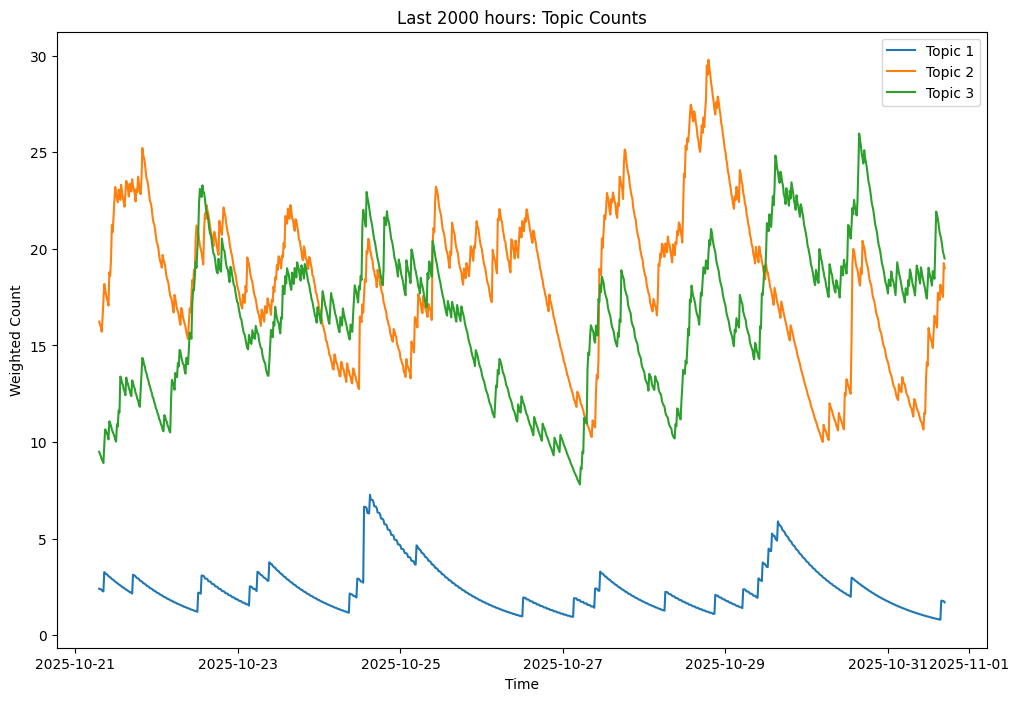

In [30]:
# Quickly graph the weighted counts for the first 2 topics over the past 500 hours to ensure smooth decay

last_500_idx = td_topics_df.index[-1000:] if len(td_topics_df) >= 500 else td_topics_df.index

plt.figure(figsize=(12, 8))
for i in range(3):
    plt.plot(last_500_idx, td_topics_df.loc[last_500_idx, td_topics_df.columns[i]], label=f'Topic {i+1}')
plt.xlabel("Time")
plt.ylabel("Weighted Count")
plt.title("Last 2000 hours: Topic Counts")
plt.legend()
plt.show()

## Time-Decayed Aggregation for Embeddings
We'll create a new Dataframe called `td_embeddings_df` which will be used as features for the models. 

Similar to what we did in the last section, we want to compute the time-decayed weighted average embedding for every hour. We'll use the same parameter values for `lookback_window` = 336h and `lambda` = 0.05 for the function:

$$weight = e^{- \lambda * HoursSincePublication}$$

One minor difference though, is that once these time-decayed weighted average embeddings have been calculated for every hour, we'll use UMAP to reduce the dimensionality of the embeddings to 20. We'll keep this modular as a function in case we want to disable it and use the full embeddings as features. For now we'll reduce dimensionality and put those into `td_embeddings_df`.

In [32]:
def compute_time_decayed_embeddings(news_df, master_df, lookback_window=336, decay_lambda=0.05, verbose=True):
    """
    Compute time-decayed weighted average embeddings (OPTIMIZED VERSION).
    
    For each timestamp in master_df, compute the weighted average embedding of articles
    published within the lookback_window, using exponential time decay.
    
    Weight formula: weight = e^(-lambda * hours_since_publication)
    
    Parameters:
        news_df: DataFrame with columns ['publishedAt', 'embedding']
        master_df: DataFrame with datetime index representing target timestamps
        lookback_window: Number of hours to look back (default: 336h = 2 weeks)
        decay_lambda: Decay rate parameter (default: 0.05)
        verbose: Whether to print progress messages (default: True)
    
    Returns:
        np.ndarray: Array of weighted average embeddings with shape (n_timestamps, embedding_dim)
    """
    
    # Convert publishedAt to datetime if needed and handle timezone
    td_embedding_news_df = news_df.copy()
    if 'publishedAt' in td_embedding_news_df.columns:
        td_embedding_news_df['publishedAt'] = pd.to_datetime(td_embedding_news_df['publishedAt'])
    else:
        raise ValueError("news_df must contain 'publishedAt' column")
    
    # Convert timezone-aware datetime to naive datetime (remove timezone info)
    if td_embedding_news_df['publishedAt'].dt.tz is not None:
        td_embedding_news_df['publishedAt'] = td_embedding_news_df['publishedAt'].dt.tz_localize(None)
    
    if verbose:
        print(f"Computing time-decayed weighted average embeddings for {len(master_df)} timestamps")
        print(f"Lookback window: {lookback_window}h, decay lambda: {decay_lambda}")
        print("Using optimized vectorized computation...")
    
    # OPTIMIZATION 1: Vectorized preprocessing of embeddings
    valid_embeddings_mask = td_embedding_news_df['embedding'].notna()
    if not valid_embeddings_mask.any():
        raise ValueError("No valid embeddings found. Check that news_df has valid embeddings.")
    
    # Get valid indices and process in one go
    valid_indices = td_embedding_news_df[valid_embeddings_mask].index
    
    # Convert embeddings to numpy array efficiently
    article_embeddings_list = []
    for idx in valid_indices:
        emb = td_embedding_news_df.loc[idx, 'embedding']
        if isinstance(emb, list):
            emb = np.array(emb, dtype=np.float32)  # Use float32 for memory efficiency
        elif not isinstance(emb, np.ndarray):
            emb = np.array(emb, dtype=np.float32)
        elif emb.dtype != np.float32:
            emb = emb.astype(np.float32)
        article_embeddings_list.append(emb)
    
    # Get embedding dimension from first valid embedding
    embedding_dim = len(article_embeddings_list[0]) if article_embeddings_list else 384
    
    # Convert to 2D array: shape (n_valid_articles, embedding_dim)
    article_embeddings_array = np.array(article_embeddings_list, dtype=np.float32)
    
    # Get valid article times (much faster than the previous approach)
    article_times_valid = td_embedding_news_df.loc[valid_indices, 'publishedAt'].values
    article_times_valid = pd.to_datetime(article_times_valid).values.astype('datetime64[ns]')
    
    # Sort articles by time for efficient searching
    sort_indices = np.argsort(article_times_valid)
    article_times_valid = article_times_valid[sort_indices]
    article_embeddings_array = article_embeddings_array[sort_indices]
    
    # Initialize output array: shape (n_timestamps, embedding_dim)
    timestamps = master_df.index.values.astype('datetime64[ns]')
    weighted_embeddings_array = np.zeros((len(timestamps), embedding_dim), dtype=np.float32)
    
    if verbose:
        print(f"Processing {len(article_embeddings_array)} valid embeddings across {len(timestamps)} timestamps")
        print("Using binary search for efficient article lookup...")
    
    # OPTIMIZATION 2: Use binary search (searchsorted) to find relevant articles efficiently
    # Convert lookback_window to timedelta64
    lookback_delta = np.timedelta64(int(lookback_window), 'h')
    
    # Pre-compute cutoff times for all timestamps
    cutoff_times = timestamps - lookback_delta
    
    # Process timestamps with progress bar
    for i in tqdm(range(len(timestamps)), desc="Processing timestamps", disable=not verbose):
        timestamp = timestamps[i]
        cutoff_time = cutoff_times[i]
        
        # OPTIMIZATION 3: Use binary search to find articles in range [cutoff_time, timestamp]
        # searchsorted finds insertion points - very fast for sorted arrays
        start_idx = np.searchsorted(article_times_valid, cutoff_time, side='left')
        end_idx = np.searchsorted(article_times_valid, timestamp, side='right')
        
        if start_idx >= end_idx:
            # No articles in this window
            continue
        
        # Get articles in the time window
        window_embeddings = article_embeddings_array[start_idx:end_idx]
        window_times = article_times_valid[start_idx:end_idx]
        
        # OPTIMIZATION 4: Vectorized hours and weights calculation
        hours_since = (timestamp - window_times).astype('timedelta64[h]').astype(np.float32)
        weights = np.exp(-decay_lambda * hours_since, dtype=np.float32)
        
        # OPTIMIZATION 5: Efficient weighted sum using einsum or broadcasting
        total_weight = np.sum(weights)
        if total_weight > 1e-10:  # Avoid division by very small numbers
            # weights: (n_articles,), window_embeddings: (n_articles, embedding_dim)
            # Result: (embedding_dim,)
            weighted_sum = np.sum(weights[:, np.newaxis] * window_embeddings, axis=0)
            weighted_embeddings_array[i] = weighted_sum / total_weight
        else:
            weighted_embeddings_array[i] = np.zeros(embedding_dim, dtype=np.float32)
    
    if verbose:
        print(f"\nCompleted time-decayed aggregation")
        print(f"Embedding shape: {weighted_embeddings_array.shape}")
    
    return weighted_embeddings_array

# Compute time-decayed weighted average embeddings
weighted_embeddings_array = compute_time_decayed_embeddings(
    news_df, master_df, lookback_window=336, decay_lambda=0.05
)

Computing time-decayed weighted average embeddings for 45867 timestamps
Lookback window: 336h, decay lambda: 0.05
Using optimized vectorized computation...
Processing 113894 valid embeddings across 45867 timestamps
Using binary search for efficient article lookup...


Processing timestamps: 100%|██████████| 45867/45867 [00:06<00:00, 6809.97it/s]


Completed time-decayed aggregation
Embedding shape: (45867, 384)


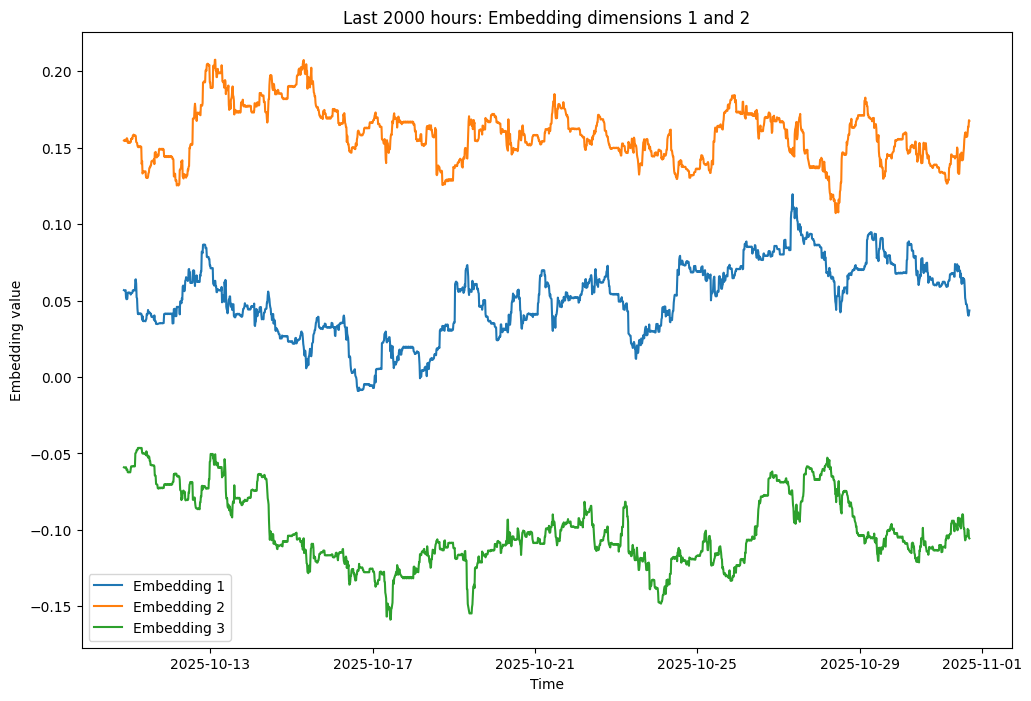

In [33]:
plt.figure(figsize=(12, 8))
last_2000 = weighted_embeddings_array[-2000:] if weighted_embeddings_array.shape[0] > 2000 else weighted_embeddings_array
ts_index = master_df.index[-last_2000.shape[0]:]
for i in range(3):
    plt.plot(ts_index, last_2000[:, i], label=f"Embedding {i+1}")
plt.xlabel("Time")
plt.ylabel("Embedding value")
plt.title("Last 2000 hours: Embedding dimensions 1 and 2")
plt.legend()
plt.show()


In [34]:
# Apply UMAP dimensionality reduction to the time-decayed embeddings
print(f"Applying UMAP to reduce embeddings from {weighted_embeddings_array.shape[1]} to 20 dimensions...")

# Removed random_state to enable full parallelism with n_jobs=-1
reducer = umap.UMAP(n_components=20, n_jobs=-1, verbose=False)
reduced_embeddings = reducer.fit_transform(weighted_embeddings_array)

# Create DataFrame with reduced embeddings
td_embeddings_df = pd.DataFrame(
    reduced_embeddings,
    index=master_df.index,
    columns=[f'embedding_dim_{i}' for i in range(20)]
)

print(f"Output shape: {td_embeddings_df.shape}")


Applying UMAP to reduce embeddings from 384 to 20 dimensions...
Output shape: (45867, 20)


In [35]:
print(td_embeddings_df.shape)
td_embeddings_df.head(5)

(45867, 20)


,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,embedding_dim_8,embedding_dim_9,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19
2020-11-07 23:00:00,13.059805,1.399202,4.344908,6.049743,4.267737,2.504277,2.865447,3.177983,4.506129,1.761112,4.324538,4.895585,4.447467,5.184615,3.576002,3.876657,4.375237,3.287874,2.476709,4.991107
2020-11-08 00:00:00,13.061092,1.400655,4.344618,6.047775,4.265537,2.506269,2.867742,3.177339,4.507905,1.760209,4.324910,4.893396,4.446722,5.185835,3.574069,3.878347,4.377346,3.289070,2.474779,4.990440
2020-11-08 01:00:00,13.059947,1.399283,4.344842,6.049672,4.267614,2.504377,2.865584,3.177927,4.506248,1.761036,4.324563,4.895457,4.447412,5.184698,3.575874,3.876759,4.375377,3.287942,2.476554,4.991067
2020-11-08 02:00:00,13.060018,1.399320,4.344867,6.049578,4.267513,2.504441,2.865660,3.177909,4.506320,1.760995,4.324574,4.895380,4.447390,5.184739,3.575799,3.876812,4.375448,3.287977,2.476475,4.991045
2020-11-08 03:00:00,13.060102,1.399341,4.344845,6.049531,4.267445,2.504488,2.865728,3.177885,4.506386,1.760957,4.324581,4.895317,4.447361,5.184775,3.575722,3.876858,4.375516,3.288018,2.476400,4.991034


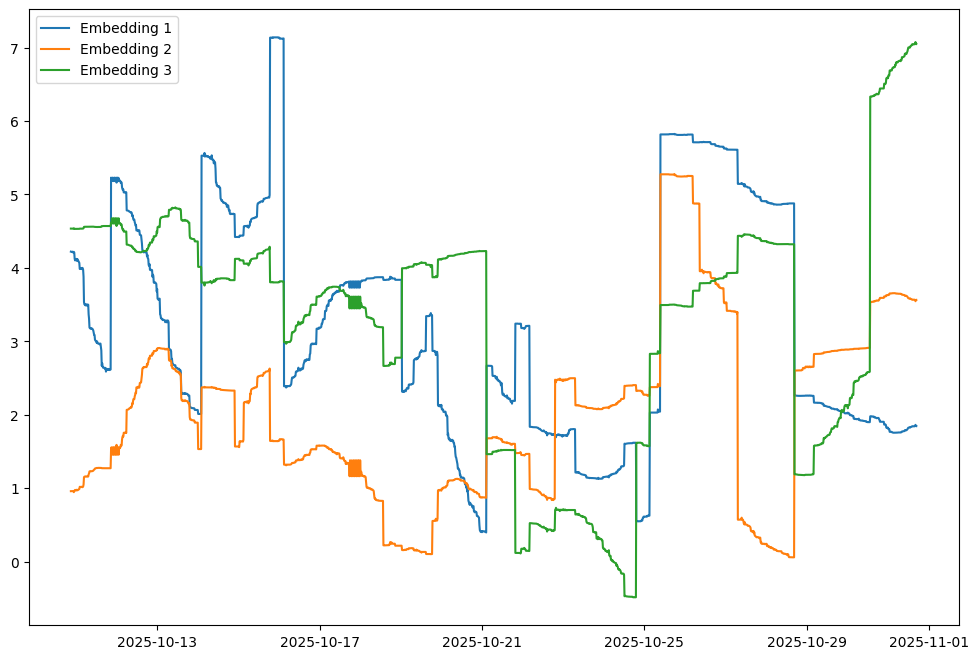

In [36]:
# Only plot the last 2000 hours for the first 5 embeddings to ensure smooth decay

plt.figure(figsize=(12, 8))
plot_df = td_embeddings_df.tail(2000)
for i in range(3):
    plt.plot(plot_df.index, plot_df[plot_df.columns[i]], label=f'Embedding {i+1}')
plt.legend()
plt.show()

now we merge all the features together

In [37]:
# Store default merged_df for baseline comparison
merged_df_default = master_df.join([td_topics_df, td_embeddings_df], how='left')
print(merged_df_default.shape)
merged_df_default.head(5)

(45867, 45)


,price,total_power,target,price_lag_24,price_lag_168,total_power_lag_24,total_power_lag_168,hour,week_of_year,month,...,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19
2020-11-07 23:00:00,35.87,130407.5,32.50,35.05,24.26,139313.4,111222.8,23,45,11,...,4.324538,4.895585,4.447467,5.184615,3.576002,3.876657,4.375237,3.287874,2.476709,4.991107
2020-11-08 00:00:00,31.71,125331.6,32.08,31.65,23.21,134679.9,105772.9,0,45,11,...,4.324910,4.893396,4.446722,5.185835,3.574069,3.878347,4.377346,3.289070,2.474779,4.990440
2020-11-08 01:00:00,31.21,124077.6,31.95,31.16,20.03,133859.6,103850.1,1,45,11,...,4.324563,4.895457,4.447412,5.184698,3.575874,3.876759,4.375377,3.287942,2.476554,4.991067
2020-11-08 02:00:00,31.30,122810.1,31.10,29.91,13.62,132950.5,107071.7,2,45,11,...,4.324574,4.895380,4.447390,5.184739,3.575799,3.876812,4.375448,3.287977,2.476475,4.991045
2020-11-08 03:00:00,31.85,122059.4,31.00,29.05,10.48,132385.8,108373.0,3,45,11,...,4.324581,4.895317,4.447361,5.184775,3.575722,3.876858,4.375516,3.288018,2.476400,4.991034


---
# Grid Search for Time-Decayed Parameters
This section performs a grid search to find optimal time-decayed parameters (`lookback_window` and `decay_lambda`) using Ridge Regression for fast exploration. We'll precompute features for all parameter combinations, then use a simplified expanding window for grid search.


In [38]:
# Define parameter grid for grid search
lookback_windows = [168, 336, 504, 672]  # 1, 2, 3, 4 weeks in hours
decay_lambdas = [0.01, 0.02, 0.05, 0.1, 0.2]

# Create all combinations
param_combinations = []
for lw in lookback_windows:
    for dl in decay_lambdas:
        param_combinations.append({'lookback_window': lw, 'decay_lambda': dl})

print(f"Total parameter combinations: {len(param_combinations)}")
print(f"Lookback windows: {lookback_windows}")
print(f"Decay lambdas: {decay_lambdas}")
print(f"\nFirst 3 combinations (showing sample):")
for i, combo in enumerate(param_combinations[:3], 1):
    print(f"{i}. lookback_window={combo['lookback_window']}h, decay_lambda={combo['decay_lambda']}")


Total parameter combinations: 20
Lookback windows: [168, 336, 504, 672]
Decay lambdas: [0.01, 0.02, 0.05, 0.1, 0.2]

First 3 combinations (showing sample):
1. lookback_window=168h, decay_lambda=0.01
2. lookback_window=168h, decay_lambda=0.02
3. lookback_window=168h, decay_lambda=0.05


In [39]:
def precompute_single_combination(params):
    """Helper function to precompute features for a single parameter combination."""
    lw = params['lookback_window']
    dl = params['decay_lambda']
    
    # Compute topic counts
    td_topics = compute_time_decayed_topic_counts(news_df, master_df, lookback_window=lw, decay_lambda=dl, verbose=False)
    
    # Compute embeddings
    weighted_embeddings = compute_time_decayed_embeddings(news_df, master_df, lookback_window=lw, decay_lambda=dl, verbose=False)
    
    # Replace UMAP with PCA for faster dimensionality reduction
    reducer = PCA(n_components=20)
    reduced_embeddings = reducer.fit_transform(weighted_embeddings)
    
    td_embeddings = pd.DataFrame(
        reduced_embeddings,
        index=master_df.index,
        columns=[f'embedding_dim_{i}' for i in range(20)]
    )
    
    return (lw, dl), (td_topics, td_embeddings)

In [44]:
# Precompute features for all parameter combinations
# This will compute time-decayed topics and embeddings for each combination
print(f"Precomputing features for {len(param_combinations)} parameter combinations...")
print("This may take a while, but will speed up the grid search significantly...\n")

# Use parallel processing to precompute features
precomputed_features = dict(
    Parallel(n_jobs=-1, verbose=10)(
        delayed(precompute_single_combination)(params)
        for params in param_combinations
    )
)

print(f"\nPrecomputation complete! Features computed for {len(precomputed_features)} parameter combinations.")
print(f"Sample keys: {list(precomputed_features.keys())[:3]}")

Precomputing features for 20 parameter combinations...
This may take a while, but will speed up the grid search significantly...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 185 concurrent workers.
Processing timestamps: 100%|██████████| 45867/45867 [00:26<00:00, 1715.92it/s]
[Parallel(n_jobs=-1)]: Done  14 out of  20 | elapsed:   50.7s remaining:   21.7s
[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed:  1.0min remaining:   10.7s



Precomputation complete! Features computed for 20 parameter combinations.
Sample keys: [(168, 0.01), (168, 0.02), (168, 0.05)]


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:  1.1min finished


In [45]:
def evaluate_single_parameter_combination(params_key, td_topics_df, td_embeddings_df, master_df, 
                                          baseline_features, train_df, val_set, news_features, retrain_frequency=168):
    """
    Evaluate a single parameter combination using Ridge Regression with simplified expanding window.
    This function is designed to be parallelized.
    
    Parameters:
        params_key: tuple of (lookback_window, decay_lambda)
        td_topics_df: Time-decayed topics DataFrame
        td_embeddings_df: Time-decayed embeddings DataFrame
        master_df: DataFrame with datetime index
        baseline_features: list of baseline feature names
        train_df: Training DataFrame (used for expanding window)
        val_set: Validation DataFrame (used for evaluation)
        news_features: list of news feature column names
        retrain_frequency: Hours between retraining (default: 168 for simplified grid search)
    
    Returns:
        Dictionary with metrics and parameter info
    """
    lw, dl = params_key
    
    # Merge features for this parameter combination
    merged_features_df = master_df.join([td_topics_df, td_embeddings_df], how='left')
    model_df = merged_features_df.dropna(subset=['target']).copy()
    
    # Re-split to ensure we're using the same train/val split
    train_size = int(len(model_df) * 0.8)
    current_train_df = model_df.iloc[:train_size].copy()
    current_val_df = model_df.iloc[train_size:train_size+len(val_set)].copy()
    
    # Simplified expanding window: retrain every retrain_frequency hours
    last_retrain_idx = 0
    all_val_predictions = []
    all_val_actuals = []
    
    for i in range(len(current_val_df)):
        # Current training window: all data from start to current validation point
        train_end_idx = len(current_train_df) + i
        if train_end_idx > len(model_df):
            break
            
        current_expanded_train = model_df.iloc[:train_end_idx].copy()
        
        # Check if we need to retrain
        if i == 0 or (i - last_retrain_idx) >= retrain_frequency:
            # Fit scaler on news features for current training data
            scaler_news = StandardScaler()
            current_news_features = current_expanded_train[news_features].fillna(0)
            scaler_news.fit(current_news_features)
            
            # Prepare advanced features with standardized news features
            X_train_news_scaled = scaler_news.transform(current_expanded_train[news_features].fillna(0))
            X_train_advanced = np.column_stack([
                current_expanded_train[baseline_features].fillna(0),
                X_train_news_scaled
            ])
            
            y_train = current_expanded_train['target']
            
            # Train Ridge Regression model
            ridge_model = Ridge(alpha=1.0, random_state=42)
            ridge_model.fit(X_train_advanced, y_train)
            
            last_retrain_idx = i
            
            # Store scaler and model for predictions
            stored_scaler = scaler_news
            stored_model = ridge_model
        
        # Make prediction on current validation point
        val_point = current_val_df.iloc[i:i+1]
        X_val_news_scaled = stored_scaler.transform(val_point[news_features].fillna(0))
        X_val_advanced = np.column_stack([
            val_point[baseline_features].fillna(0),
            X_val_news_scaled
        ])
        
        y_val_pred = stored_model.predict(X_val_advanced)[0]
        y_val_actual = val_point['target'].values[0]
        
        all_val_predictions.append(y_val_pred)
        all_val_actuals.append(y_val_actual)
    
    # Calculate metrics
    if len(all_val_predictions) > 0:
        mae = mean_absolute_error(all_val_actuals, all_val_predictions)
        rmse = np.sqrt(mean_squared_error(all_val_actuals, all_val_predictions))
        
        return {
            'lookback_window': lw,
            'decay_lambda': dl,
            'mae': mae,
            'rmse': rmse,
            'params_key': params_key
        }
    else:
        return {
            'lookback_window': lw,
            'decay_lambda': dl,
            'mae': np.inf,
            'rmse': np.inf,
            'params_key': params_key
        }


def grid_search_time_decay_params(precomputed_features, master_df, baseline_features, 
                                   train_df, val_set, retrain_frequency=168):
    """
    Grid search using Ridge Regression with simplified expanding window.
    Now parallelized using joblib for GPU cluster optimization.
    
    Parameters:
        precomputed_features: dict of {(lookback_window, decay_lambda): (td_topics_df, td_embeddings_df)}
        master_df: DataFrame with datetime index
        baseline_features: list of baseline feature names
        train_df: Training DataFrame (used for expanding window)
        val_set: Validation DataFrame (used for evaluation)
        retrain_frequency: Hours between retraining (default: 168 for simplified grid search)
    
    Returns:
        List of top 5 parameter combinations with metrics, sorted by validation MAE
    """
    # Get topic and embedding column names from first precomputed feature set
    first_key = list(precomputed_features.keys())[0]
    td_topics_sample, td_embeddings_sample = precomputed_features[first_key]
    topic_cols = list(td_topics_sample.columns)
    embedding_cols = list(td_embeddings_sample.columns)
    news_features = topic_cols + embedding_cols
    
    print(f"Grid searching {len(precomputed_features)} parameter combinations...")
    print(f"Using Ridge Regression with retraining every {retrain_frequency} hours")
    print(f"Parallelizing evaluation across parameter combinations using joblib...\n")
    
    # Parallelize evaluation across all parameter combinations
    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(evaluate_single_parameter_combination)(
            params_key, td_topics_df, td_embeddings_df, master_df,
            baseline_features, train_df, val_set, news_features, retrain_frequency
        )
        for params_key, (td_topics_df, td_embeddings_df) in precomputed_features.items()
    )
    
    # Sort by MAE (ascending - lower is better)
    results_sorted = sorted(results, key=lambda x: x['mae'])
    
    # Print results summary
    print(f"\n{'='*80}")
    print("TOP 5 PARAMETER COMBINATIONS:")
    print(f"{'='*80}")
    top_5 = results_sorted[:5]
    for i, result in enumerate(top_5, 1):
        print(f"{i}. lookback_window={result['lookback_window']}h, decay_lambda={result['decay_lambda']} | "
              f"MAE={result['mae']:.2f}, RMSE={result['rmse']:.2f}")
    
    return top_5


In [46]:
# Prepare data splits for grid search (using default features)
# We need train_df and val_set to pass to grid search function
model_df_default = merged_df_default.dropna(subset=['target']).copy()

# Define baseline features (will be used for all combinations)
baseline_features = [
    'price_lag_24', 'price_lag_168', 
    'total_power_lag_24', 'total_power_lag_168',
    'hour', 'month', 'day_of_week', 'day_of_year', 'week_of_year'
]

# Split data into train (80%) and test (20%)
train_size = int(len(model_df_default) * 0.8)
train_df = model_df_default.iloc[:train_size].copy()
test_df = model_df_default.iloc[train_size:].copy()

print(f"Train set: {len(train_df)} samples from {train_df.index[0]} to {train_df.index[-1]}")
print(f"Test set: {len(test_df)} samples from {test_df.index[0]} to {test_df.index[-1]}")

# Split train into train (60%) and validation (40%)
train_len = int(len(train_df) * 0.6)
train_set = train_df.iloc[:train_len].copy()
val_set = train_df.iloc[train_len:].copy()

print(f"\nTrain subset: {len(train_set)} samples")
print(f"Validation subset: {len(val_set)} samples")


Train set: 36693 samples from 2020-11-07 23:00:00 to 2025-01-14 19:00:00
Test set: 9174 samples from 2025-01-14 20:00:00 to 2025-10-31 16:45:00

Train subset: 22015 samples
Validation subset: 14678 samples


In [47]:
# Run grid search to find top 5 parameter combinations
top_5_combinations = grid_search_time_decay_params(
    precomputed_features=precomputed_features,
    master_df=master_df,
    baseline_features=baseline_features,
    train_df=train_df,
    val_set=val_set,
    retrain_frequency=168  # Simplified: retrain every 168 hours (1 week)
)


Grid searching 20 parameter combinations...
Using Ridge Regression with retraining every 168 hours
Parallelizing evaluation across parameter combinations using joblib...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 185 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  20 | elapsed:   31.4s remaining:  4.7min
[Parallel(n_jobs=-1)]: Done   5 out of  20 | elapsed:   37.0s remaining:  1.9min
[Parallel(n_jobs=-1)]: Done   8 out of  20 | elapsed:   37.5s remaining:   56.3s
[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed:   38.0s remaining:   31.1s
[Parallel(n_jobs=-1)]: Done  14 out of  20 | elapsed:   38.9s remaining:   16.7s
[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed:   39.4s remaining:    6.9s



TOP 5 PARAMETER COMBINATIONS:
1. lookback_window=504h, decay_lambda=0.2 | MAE=30.11, RMSE=43.03
2. lookback_window=336h, decay_lambda=0.2 | MAE=30.11, RMSE=43.03
3. lookback_window=672h, decay_lambda=0.2 | MAE=30.11, RMSE=43.03
4. lookback_window=168h, decay_lambda=0.2 | MAE=30.11, RMSE=43.03
5. lookback_window=504h, decay_lambda=0.1 | MAE=30.38, RMSE=43.19


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:   40.0s finished


---
# Training Full Models on Top 5 Combinations
Now we train the full models (XGBoost and Linear Regression) on the top 5 parameter combinations using the full expanding window approach (retrain every 24 hours).


In [51]:
def train_full_models_on_combination(params_key, td_topics_df, td_embeddings_df, master_df, 
                                      baseline_features, train_df, val_set, retrain_frequency=24, verbose=True):
    """
    Train full models (XGBoost and Linear Regression) on a specific parameter combination
    using full expanding window (retrain every 24 hours).
    
    Parameters:
        params_key: tuple of (lookback_window, decay_lambda)
        td_topics_df: Time-decayed topics DataFrame
        td_embeddings_df: Time-decayed embeddings DataFrame
        master_df: DataFrame with datetime index
        baseline_features: list of baseline feature names
        train_df: Training DataFrame
        val_set: Validation DataFrame
        retrain_frequency: Hours between retraining (default: 24 for full training)
        verbose: Whether to print progress messages (default: True)
    
    Returns:
        Dictionary with models, predictions, and metrics
    """
    lw, dl = params_key
    
    # Merge features for this parameter combination
    merged_features_df = master_df.join([td_topics_df, td_embeddings_df], how='left')
    model_df = merged_features_df.dropna(subset=['target']).copy()
    
    # Get feature columns
    topic_cols = list(td_topics_df.columns)
    embedding_cols = list(td_embeddings_df.columns)
    news_features = topic_cols + embedding_cols
    
    # Re-split to ensure we're using the same train/val split
    train_size = int(len(model_df) * 0.8)
    current_train_df = model_df.iloc[:train_size].copy()
    current_val_df = model_df.iloc[train_size:train_size+len(val_set)].copy()
    
    # Train subset for initial training
    train_len = int(len(current_train_df) * 0.6)
    train_subset = current_train_df.iloc[:train_len].copy()
    
    # Expanding window training: retrain every retrain_frequency hours
    last_retrain_idx = 0
    all_val_predictions = {'lr_baseline': [], 'lr_advanced': [], 'xgb_baseline': [], 'xgb_advanced': []}
    all_val_actuals = []
    
    models = {'lr_baseline': None, 'lr_advanced': None, 'xgb_baseline': None, 'xgb_advanced': None}
    
    if verbose:
        print(f"Training full models for lookback_window={lw}h, decay_lambda={dl}...")
    
    # Use tqdm only if verbose, otherwise disable it
    val_iterator = tqdm(range(len(current_val_df)), desc=f"Expanding window (full training)", leave=False, disable=not verbose)
    
    for i in val_iterator:
        # Current training window: all data from start to current validation point
        train_end_idx = len(train_subset) + i
        if train_end_idx > len(model_df):
            break
            
        current_expanded_train = model_df.iloc[:train_end_idx].copy()
        
        # Check if we need to retrain
        if i == 0 or (i - last_retrain_idx) >= retrain_frequency:
            # Prepare baseline features (no news features)
            X_train_baseline = current_expanded_train[baseline_features].fillna(0)
            
            # Fit scaler on news features for current training data
            scaler_news = StandardScaler()
            current_news_features = current_expanded_train[news_features].fillna(0)
            scaler_news.fit(current_news_features)
            
            # Prepare advanced features with standardized news features
            X_train_news_scaled = scaler_news.transform(current_expanded_train[news_features].fillna(0))
            X_train_advanced = np.column_stack([
                current_expanded_train[baseline_features].fillna(0),
                X_train_news_scaled
            ])
            
            y_train = current_expanded_train['target']
            
            # Train baseline models
            models['lr_baseline'] = LinearRegression()
            models['lr_baseline'].fit(X_train_baseline, y_train)
            
            models['xgb_baseline'] = XGBRegressor(
                n_estimators=100,
                max_depth=5,
                learning_rate=0.1,
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
            models['xgb_baseline'].fit(X_train_baseline, y_train)
            
            # Train advanced models
            models['lr_advanced'] = LinearRegression()
            models['lr_advanced'].fit(X_train_advanced, y_train)
            
            models['xgb_advanced'] = XGBRegressor(
                n_estimators=100,
                max_depth=5,
                learning_rate=0.1,
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
            models['xgb_advanced'].fit(X_train_advanced, y_train)
            
            last_retrain_idx = i
            
            # Store scaler for predictions
            stored_scaler = scaler_news
        
        # Make predictions on current validation point
        val_point = current_val_df.iloc[i:i+1]
        X_val_baseline = val_point[baseline_features].fillna(0)
        X_val_news_scaled = stored_scaler.transform(val_point[news_features].fillna(0))
        X_val_advanced = np.column_stack([
            val_point[baseline_features].fillna(0),
            X_val_news_scaled
        ])
        
        y_val_actual = val_point['target'].values[0]
        all_val_actuals.append(y_val_actual)
        
        # Make predictions for all models
        all_val_predictions['lr_baseline'].append(models['lr_baseline'].predict(X_val_baseline)[0])
        all_val_predictions['xgb_baseline'].append(models['xgb_baseline'].predict(X_val_baseline)[0])
        all_val_predictions['lr_advanced'].append(models['lr_advanced'].predict(X_val_advanced)[0])
        all_val_predictions['xgb_advanced'].append(models['xgb_advanced'].predict(X_val_advanced)[0])
    
    # Calculate metrics for all models
    metrics = {}
    for model_name in ['lr_baseline', 'lr_advanced', 'xgb_baseline', 'xgb_advanced']:
        if len(all_val_predictions[model_name]) > 0:
            mae = mean_absolute_error(all_val_actuals, all_val_predictions[model_name])
            rmse = np.sqrt(mean_squared_error(all_val_actuals, all_val_predictions[model_name]))
            metrics[model_name] = {'mae': mae, 'rmse': rmse}
        else:
            metrics[model_name] = {'mae': np.inf, 'rmse': np.inf}
    
    return {
        'params_key': params_key,
        'lookback_window': lw,
        'decay_lambda': dl,
        'predictions': all_val_predictions,
        'actuals': all_val_actuals,
        'metrics': metrics
    }

In [54]:
from joblib import Parallel, delayed

def train_single_combination(combo, precomputed_features, master_df, baseline_features, train_df, val_set):
    """Wrapper function for parallel execution"""
    params_key = combo['params_key']
    td_topics_df, td_embeddings_df = precomputed_features[params_key]
    
    result = train_full_models_on_combination(
        params_key=params_key,
        td_topics_df=td_topics_df,
        td_embeddings_df=td_embeddings_df,
        master_df=master_df,
        baseline_features=baseline_features,
        train_df=train_df,
        val_set=val_set,
        retrain_frequency=24,
        verbose=False
    )
    return result

# Train full models on top 5 combinations in parallel
print(f"Training full models on {len(top_5_combinations)} combinations in parallel...")
top_5_results = Parallel(n_jobs=-1, verbose=10)(
    delayed(train_single_combination)(
        combo, precomputed_features, master_df, baseline_features, train_df, val_set
    )
    for combo in top_5_combinations
)

print(f"\nCompleted training on top {len(top_5_results)} combinations")

Training full models on 5 combinations in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 185 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  5.8min remaining:  8.7min
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:  5.8min remaining:  3.9min



Completed training on top 5 combinations


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  5.8min finished


In [55]:
# Evaluate top 5 combinations on validation set and select best
print(f"\n{'='*80}")
print("VALIDATION SET PERFORMANCE - TOP 5 COMBINATIONS:")
print(f"{'='*80}")
print(f"{'Rank':<6} {'Lookback':<12} {'Decay Lambda':<15} {'LR-Base MAE':<12} {'LR-Adv MAE':<12} {'XGB-Base MAE':<12} {'XGB-Adv MAE':<12}")
print("-"*80)

# Sort by XGBoost Advanced MAE (best model)
top_5_results_sorted = sorted(top_5_results, key=lambda x: x['metrics']['xgb_advanced']['mae'])

for i, result in enumerate(top_5_results_sorted, 1):
    print(f"{i:<6} {result['lookback_window']:<12} {result['decay_lambda']:<15.2f} "
          f"{result['metrics']['lr_baseline']['mae']:<12.2f} "
          f"{result['metrics']['lr_advanced']['mae']:<12.2f} "
          f"{result['metrics']['xgb_baseline']['mae']:<12.2f} "
          f"{result['metrics']['xgb_advanced']['mae']:<12.2f}")

# Select best combination (lowest XGBoost Advanced MAE)
best_result = top_5_results_sorted[0]
best_params = best_result['params_key']

print(f"\n{'='*80}")
print(f"BEST PARAMETER COMBINATION (based on XGBoost Advanced validation MAE):")
print(f"  lookback_window: {best_result['lookback_window']}h")
print(f"  decay_lambda: {best_result['decay_lambda']}")
print(f"  XGBoost Advanced Validation MAE: {best_result['metrics']['xgb_advanced']['mae']:.2f}")
print(f"  XGBoost Advanced Validation RMSE: {best_result['metrics']['xgb_advanced']['rmse']:.2f}")
print(f"{'='*80}")



VALIDATION SET PERFORMANCE - TOP 5 COMBINATIONS:
Rank   Lookback     Decay Lambda    LR-Base MAE  LR-Adv MAE   XGB-Base MAE XGB-Adv MAE 
--------------------------------------------------------------------------------
1      168          0.20            30.90        31.88        29.17        30.84       
2      504          0.20            30.90        31.88        29.17        30.87       
3      336          0.20            30.90        31.88        29.17        30.89       
4      672          0.20            30.90        31.88        29.17        30.97       
5      504          0.10            30.90        32.11        29.17        31.04       

BEST PARAMETER COMBINATION (based on XGBoost Advanced validation MAE):
  lookback_window: 168h
  decay_lambda: 0.2
  XGBoost Advanced Validation MAE: 30.84
  XGBoost Advanced Validation RMSE: 44.50


---
# Final Evaluation on Test Set
Retrain the best model on the full training set and evaluate on the test set (to prevent data leakage).


In [56]:
# Retrain final best model on full training set and evaluate on test set
best_lw, best_dl = best_params
td_topics_best, td_embeddings_best = precomputed_features[best_params]

print(f"Retraining final best model on full training set...")
print(f"Parameters: lookback_window={best_lw}h, decay_lambda={best_dl}")

# Merge features for best parameter combination
merged_features_best = master_df.join([td_topics_best, td_embeddings_best], how='left')
model_df_best = merged_features_best.dropna(subset=['target']).copy()

# Get feature columns
topic_cols_best = list(td_topics_best.columns)
embedding_cols_best = list(td_embeddings_best.columns)
news_features_best = topic_cols_best + embedding_cols_best

# Prepare training data (80% split)
train_size = int(len(model_df_best) * 0.8)
train_df_best = model_df_best.iloc[:train_size].copy()
test_df_best = model_df_best.iloc[train_size:].copy()

# Fit scaler on full training data
scaler_news_best = StandardScaler()
train_news_features = train_df_best[news_features_best].fillna(0)
scaler_news_best.fit(train_news_features)

# Prepare features
X_train_baseline = train_df_best[baseline_features].fillna(0)
X_train_news_scaled = scaler_news_best.transform(train_df_best[news_features_best].fillna(0))
X_train_advanced = np.column_stack([X_train_baseline, X_train_news_scaled])
y_train = train_df_best['target']

# Train final models on full training set (all 4 models)
final_models_best = {
    'lr_baseline': LinearRegression(),
    'lr_advanced': LinearRegression(),
    'xgb_baseline': XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    'xgb_advanced': XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
}

# Train baseline models
final_models_best['lr_baseline'].fit(X_train_baseline, y_train)
final_models_best['xgb_baseline'].fit(X_train_baseline, y_train)

# Train advanced models
final_models_best['lr_advanced'].fit(X_train_advanced, y_train)
final_models_best['xgb_advanced'].fit(X_train_advanced, y_train)

print("Final models trained!")

# Prepare test features
X_test_baseline = test_df_best[baseline_features].fillna(0)
X_test_news_scaled = scaler_news_best.transform(test_df_best[news_features_best].fillna(0))
X_test_advanced = np.column_stack([X_test_baseline, X_test_news_scaled])
y_test = test_df_best['target']

# Make predictions for all models
predictions_best = {}
predictions_best['lr_baseline'] = final_models_best['lr_baseline'].predict(X_test_baseline)
predictions_best['xgb_baseline'] = final_models_best['xgb_baseline'].predict(X_test_baseline)
predictions_best['lr_advanced'] = final_models_best['lr_advanced'].predict(X_test_advanced)
predictions_best['xgb_advanced'] = final_models_best['xgb_advanced'].predict(X_test_advanced)

# Calculate metrics for all models
from sklearn.metrics import r2_score
metrics_best = {}
model_names = ['lr_baseline', 'lr_advanced', 'xgb_baseline', 'xgb_advanced']

for model_name in model_names:
    mae = mean_absolute_error(y_test, predictions_best[model_name])
    mse = mean_squared_error(y_test, predictions_best[model_name])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions_best[model_name])
    metrics_best[model_name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    
    print(f"\n{model_name} (Test Set):")
    print(f"  MAE:  {mae:.2f}")
    print(f"  MSE:  {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²:   {r2:.3f}")

print("\nFinal evaluation completed!")


Retraining final best model on full training set...
Parameters: lookback_window=168h, decay_lambda=0.2
Final models trained!

lr_baseline (Test Set):
  MAE:  30.14
  MSE:  1855.55
  RMSE: 43.08
  R²:   0.380

lr_advanced (Test Set):
  MAE:  30.81
  MSE:  1901.26
  RMSE: 43.60
  R²:   0.364

xgb_baseline (Test Set):
  MAE:  28.51
  MSE:  1715.56
  RMSE: 41.42
  R²:   0.427

xgb_advanced (Test Set):
  MAE:  29.61
  MSE:  1795.75
  RMSE: 42.38
  R²:   0.400

Final evaluation completed!


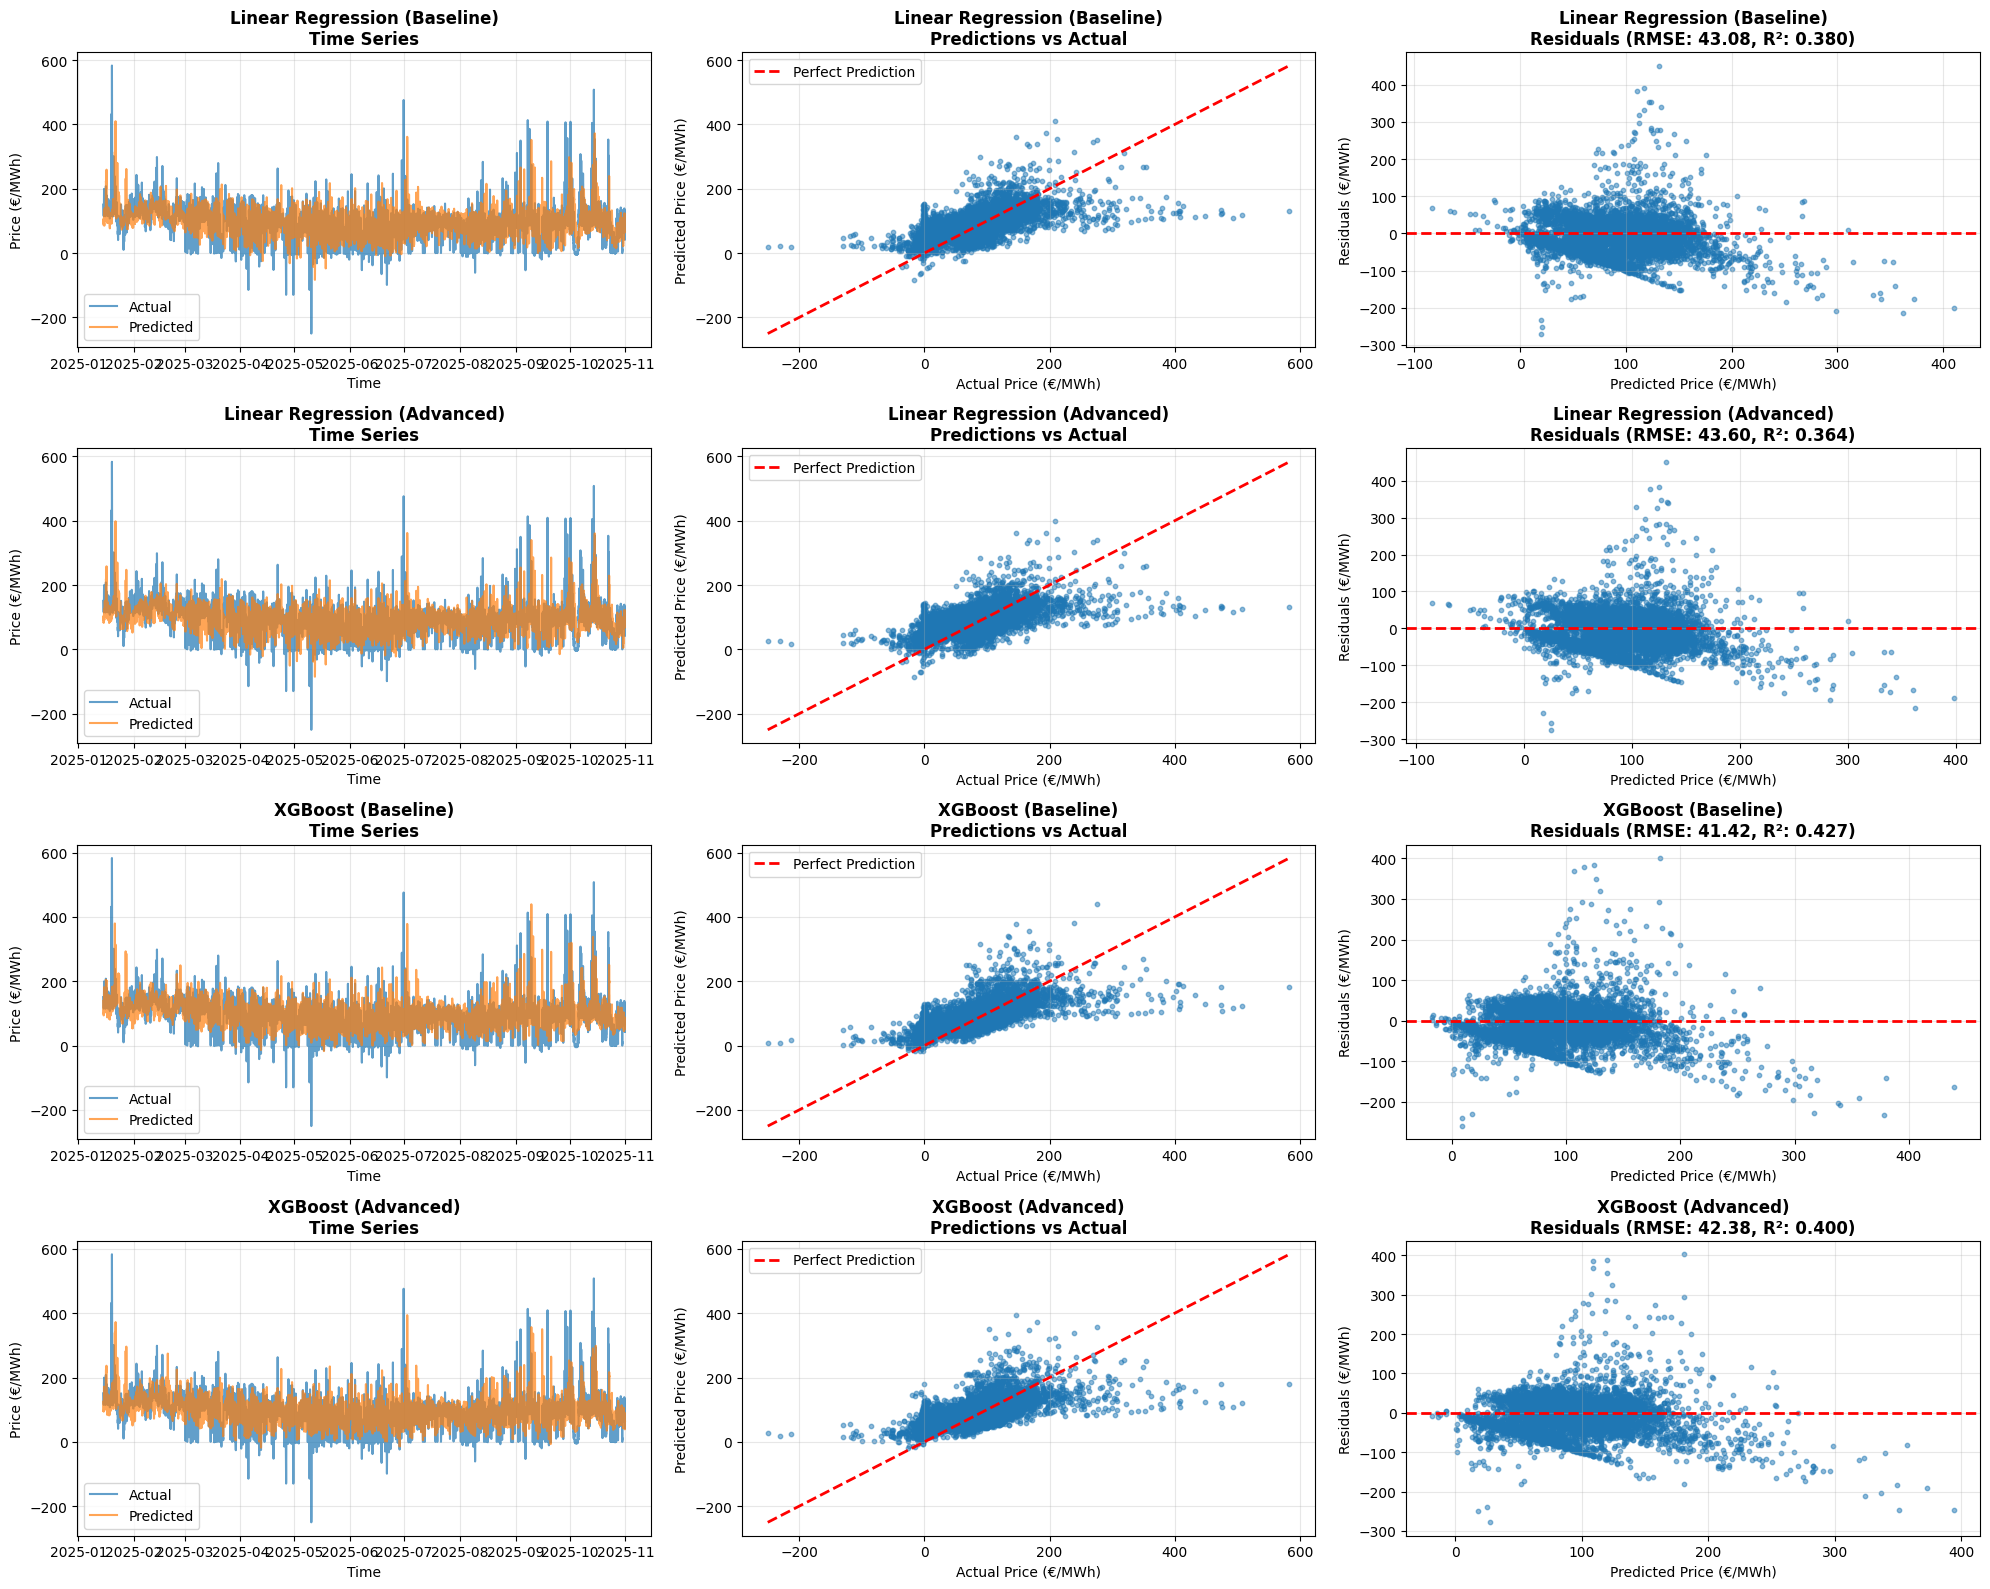

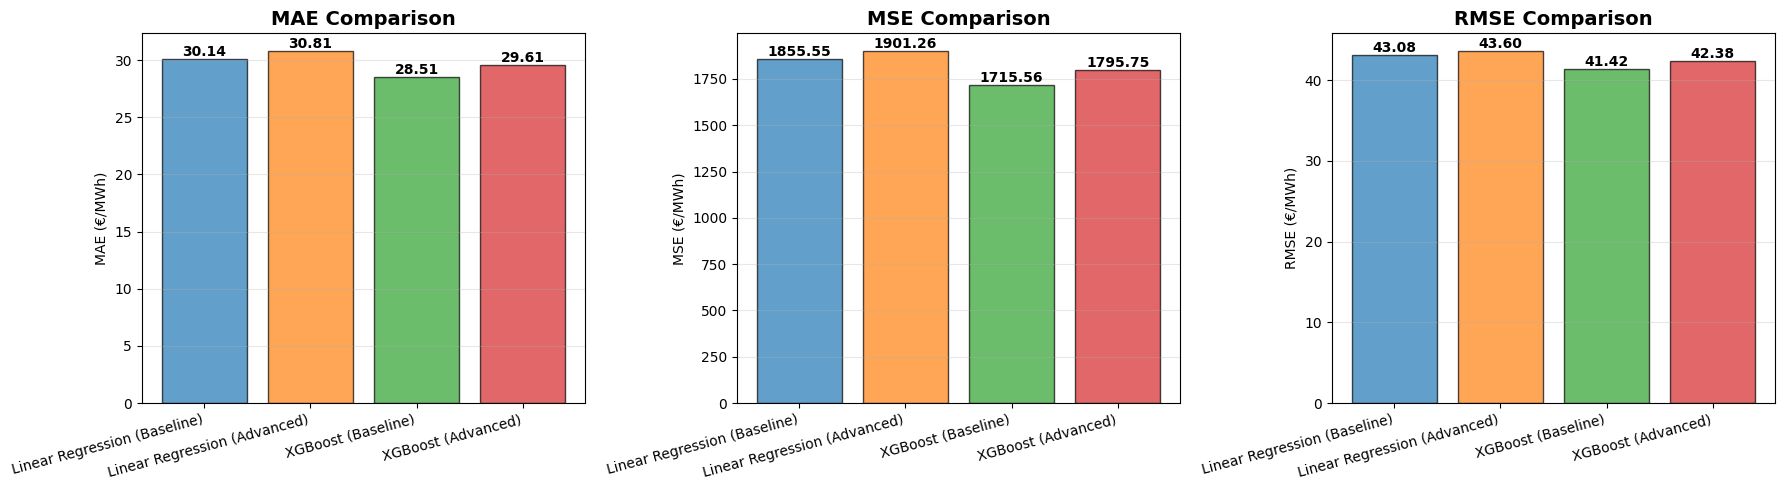


PERFORMANCE SUMMARY
Model                          MAE          MSE          RMSE         R²          
--------------------------------------------------------------------------------
Linear Regression (Baseline)   30.14        1855.55      43.08        0.380       
Linear Regression (Advanced)   30.81        1901.26      43.60        0.364       
XGBoost (Baseline)             28.51        1715.56      41.42        0.427       
XGBoost (Advanced)             29.61        1795.75      42.38        0.400       


In [57]:
# Create comprehensive performance plots for all models using best parameter combination
from sklearn.metrics import r2_score

fig = plt.figure(figsize=(20, 16))

# Model names for display
model_display_names = {
    'lr_baseline': 'Linear Regression (Baseline)',
    'lr_advanced': 'Linear Regression (Advanced)',
    'xgb_baseline': 'XGBoost (Baseline)',
    'xgb_advanced': 'XGBoost (Advanced)'
}

# Create subplots: 4 rows x 3 columns
# Row 1: Predictions vs Actual (time series)
# Row 2: Predictions vs Actual (scatter)
# Row 3: Residuals
# Row 4: Metrics comparison

for idx, model_name in enumerate(['lr_baseline', 'lr_advanced', 'xgb_baseline', 'xgb_advanced']):
    row = idx
    
    # Plot 1: Time series - Predictions vs Actual
    ax1 = plt.subplot(4, 3, row * 3 + 1)
    ax1.plot(test_df_best.index, y_test.values, label='Actual', alpha=0.7, linewidth=1.5)
    ax1.plot(test_df_best.index, predictions_best[model_name], label='Predicted', alpha=0.7, linewidth=1.5)
    ax1.set_title(f'{model_display_names[model_name]}\nTime Series', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price (€/MWh)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Scatter - Predictions vs Actual
    ax2 = plt.subplot(4, 3, row * 3 + 2)
    ax2.scatter(y_test.values, predictions_best[model_name], alpha=0.5, s=10)
    # Add perfect prediction line
    min_val = min(y_test.min(), min(predictions_best[model_name]))
    max_val = max(y_test.max(), max(predictions_best[model_name]))
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    ax2.set_title(f'{model_display_names[model_name]}\nPredictions vs Actual', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Actual Price (€/MWh)')
    ax2.set_ylabel('Predicted Price (€/MWh)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Calculate R² for display
    r2 = r2_score(y_test, predictions_best[model_name])
    
    # Plot 3: Residuals
    ax3 = plt.subplot(4, 3, row * 3 + 3)
    residuals = y_test.values - predictions_best[model_name]
    ax3.scatter(predictions_best[model_name], residuals, alpha=0.5, s=10)
    ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax3.set_title(f'{model_display_names[model_name]}\nResiduals (RMSE: {metrics_best[model_name]["RMSE"]:.2f}, R²: {r2:.3f})', 
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('Predicted Price (€/MWh)')
    ax3.set_ylabel('Residuals (€/MWh)')
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create a separate figure for metrics comparison
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_types = ['MAE', 'MSE', 'RMSE']
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for metric_idx, metric_type in enumerate(metric_types):
    ax = axes[metric_idx]
    values = [metrics_best[model][metric_type] for model in ['lr_baseline', 'lr_advanced', 'xgb_baseline', 'xgb_advanced']]
    bars = ax.bar(range(len(model_display_names)), values, color=model_colors, alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}',
                ha='center', va='bottom', fontweight='bold')
    
    ax.set_xticks(range(len(model_display_names)))
    ax.set_xticklabels([model_display_names[m] for m in ['lr_baseline', 'lr_advanced', 'xgb_baseline', 'xgb_advanced']], 
                       rotation=15, ha='right')
    ax.set_ylabel(f'{metric_type} (€/MWh)')
    ax.set_title(f'{metric_type} Comparison', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)
print(f"{'Model':<30} {'MAE':<12} {'MSE':<12} {'RMSE':<12} {'R²':<12}")
print("-"*80)
for model_name in ['lr_baseline', 'lr_advanced', 'xgb_baseline', 'xgb_advanced']:
    r2 = r2_score(y_test, predictions_best[model_name])
    print(f"{model_display_names[model_name]:<30} "
          f"{metrics_best[model_name]['MAE']:<12.2f} "
          f"{metrics_best[model_name]['MSE']:<12.2f} "
          f"{metrics_best[model_name]['RMSE']:<12.2f} "
          f"{r2:<12.3f}")
print("="*80)
